# 📦 Outlier Detection

> **Folder:** `01_Data_Preprocessing / Outlier_Detection`  
> **Notebook:** `outlier_detection.ipynb`  
> **Author:** Hamna Munir

---

## 🎯 Objectives

By the end of this notebook, you will:

- Understand **what outliers are** and the 3 types (point, contextual, collective)
- Apply **8 outlier detection techniques** with real examples
- **Visualize** outliers using box plots, scatter plots, and score distributions
- Know **when to remove, cap, or keep** outliers
- Avoid the critical mistake of **applying detection on the full dataset** before splitting

---

## 📚 Techniques Covered

| # | Technique | Type | Best For |
|---|-----------|------|----------|
| 1 | Z-Score | Statistical | Normal, univariate |
| 2 | IQR Method | Statistical | Skewed, univariate |
| 3 | Modified Z-Score (MAD) | Statistical | Robust univariate |
| 4 | Isolation Forest | ML (Tree) | High-dimensional |
| 5 | Local Outlier Factor | ML (Density) | Varying density |
| 6 | DBSCAN | ML (Clustering) | Spatial / noise |
| 7 | Elliptic Envelope | Statistical | Gaussian multivariate |
| 8 | Winsorization | Statistical | Cap, retain rows |

---
## ⚙️ 0. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


---
## 📊 1. Load & Explore Dataset

In [2]:
# ── Synthetic Dataset with Injected Outliers ─────────────────────────────
np.random.seed(42)
n = 200

data = {
    'Age'    : np.concatenate([np.random.randint(20, 60, n - 5),
                               [150, -10, 200, 180, 999]]),
    'Salary' : np.concatenate([np.random.randint(30_000, 150_000, n - 5),
                               [5_000_000, -1_000, 4_500_000, 3_000_000, 0]]),
    'Score'  : np.random.uniform(0, 100, n),
    'Target' : np.random.randint(0, 2, n),
}

df = pd.DataFrame(data)
feature_cols = ['Age', 'Salary', 'Score']

print(f'Shape: {df.shape}')
df.head()

Shape: (200, 4)


,Age,Salary,Score,Target
0,58,119045,55.2820,0
1,48,64698,29.6510,1
2,34,140078,41.9781,1
3,27,110623,25.6207,1
4,40,52671,61.1514,0


In [3]:
# ── Descriptive Statistics ───────────────────────────────────────────────
df[feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,200.0000,46.2400,70.8917,-10.0000,28.0000,42.0000,51.0000,999.0000
Salary,200.0000,148274.1850,509285.9353,-1000.0000,57473.5000,84142.5000,120904.2500,5000000.0000
Score,200.0000,49.6940,28.7158,0.5185,25.0193,49.6299,73.0441,99.5931


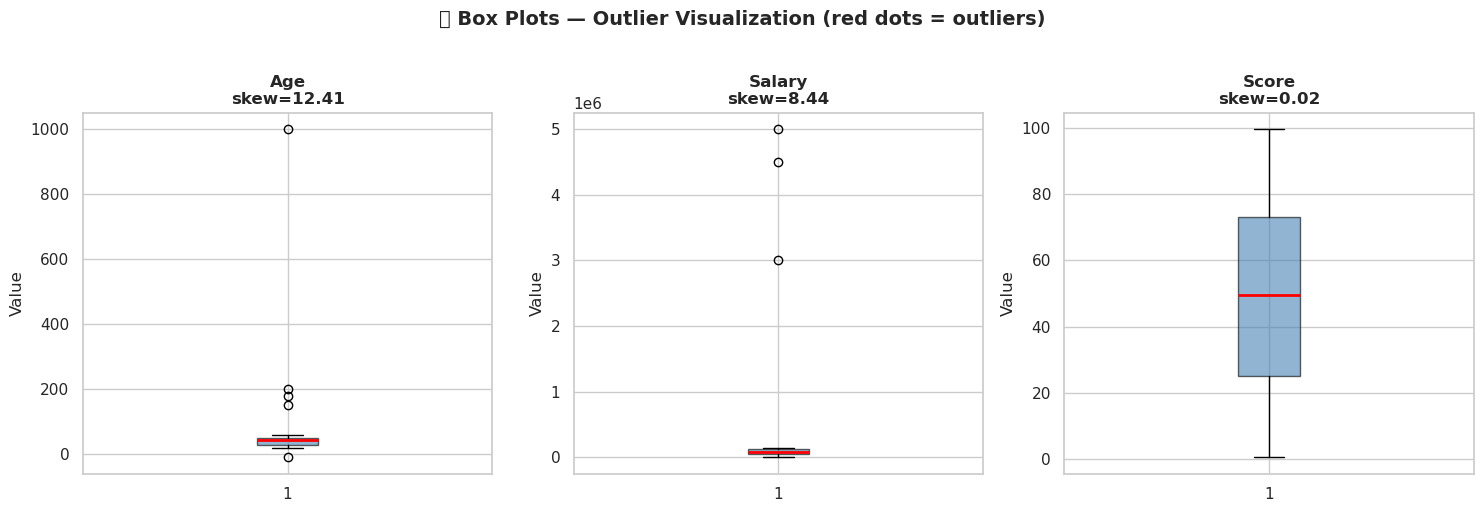

In [4]:
# ── Box Plots — Visualize Outliers ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, feature_cols):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', color='crimson', markersize=6))
    ax.set_title(f'{col}\nskew={df[col].skew():.2f}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Value')

plt.suptitle('📦 Box Plots — Outlier Visualization (red dots = outliers)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [5]:
# ── Outlier Summary ──────────────────────────────────────────────────────
summary_rows = []
for col in feature_cols:
    z_cnt   = (np.abs(stats.zscore(df[col])) > 3).sum()
    Q1, Q3  = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR     = Q3 - Q1
    iqr_cnt = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    summary_rows.append({
        'Column'           : col,
        'Z-Score Outliers' : z_cnt,
        'IQR Outliers'     : iqr_cnt,
        'Skewness'         : round(df[col].skew(), 4),
        'Min'              : df[col].min(),
        'Max'              : df[col].max(),
    })

pd.DataFrame(summary_rows)

,Column,Z-Score Outliers,IQR Outliers,Skewness,Min,Max
0,Age,1,5,12.4120,-10.0000,999.0000
1,Salary,3,3,8.4427,-1000.0000,5000000.0000
2,Score,0,0,0.0206,0.5185,99.5931


---
## 1️⃣ Z-Score Method

> **Formula:** `Z = (X - μ) / σ` → **|Z| > 3 = outlier**
>
> ⚠️ Assumes normally distributed data. Sensitive to its own outliers.

Z-Score outliers in "Age": 1
[999]


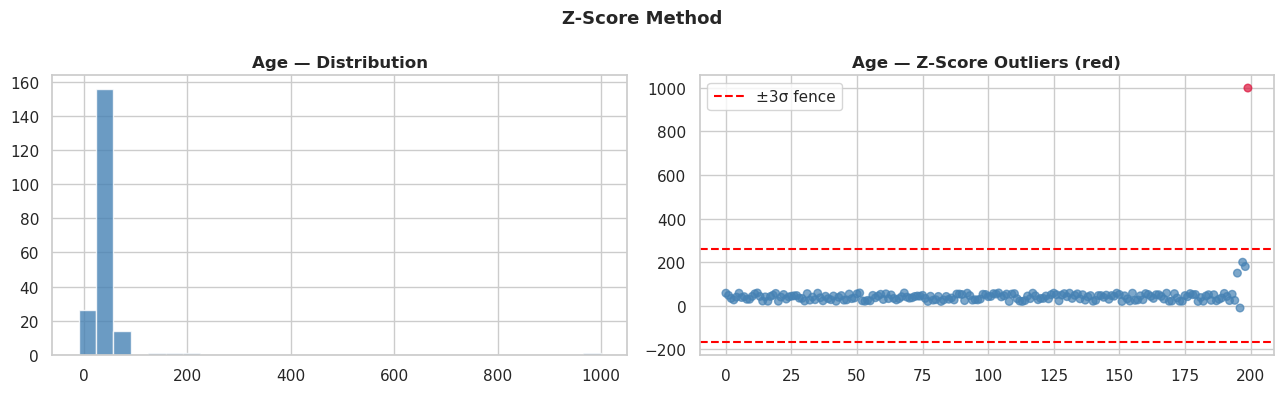

In [6]:
col = 'Age'
z_scores = np.abs(stats.zscore(df[col]))
outlier_mask_z = z_scores > 3

print(f'Z-Score outliers in "{col}": {outlier_mask_z.sum()}')
print(df[col][outlier_mask_z].values)

# ── Plot ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title(f'{col} — Distribution', fontweight='bold')

axes[1].scatter(range(len(df)), df[col],
                c=np.where(outlier_mask_z, 'crimson', 'steelblue'), alpha=0.7, s=30)
axes[1].axhline(df[col].mean() + 3 * df[col].std(), color='red',
                linestyle='--', label='±3σ fence')
axes[1].axhline(df[col].mean() - 3 * df[col].std(), color='red', linestyle='--')
axes[1].set_title(f'{col} — Z-Score Outliers (red)', fontweight='bold')
axes[1].legend()

plt.suptitle('Z-Score Method', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2️⃣ IQR Method

> **Formula:** `IQR = Q3 - Q1` → Fence: `[Q1 - 1.5×IQR, Q3 + 1.5×IQR]`
>
> ✅ Robust to non-normal distributions. The method behind box plots.

Q1=57,474  Q3=120,904  IQR=63,431
Lower Fence=-37,673  Upper Fence=216,050
IQR Outliers in "Salary": 3


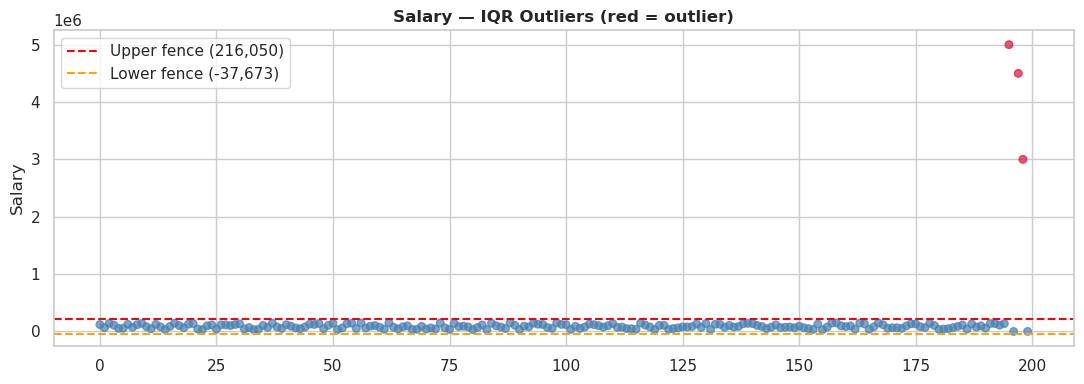

In [7]:
col = 'Salary'
Q1  = df[col].quantile(0.25)
Q3  = df[col].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_mask_iqr = (df[col] < lower) | (df[col] > upper)

print(f'Q1={Q1:,.0f}  Q3={Q3:,.0f}  IQR={IQR:,.0f}')
print(f'Lower Fence={lower:,.0f}  Upper Fence={upper:,.0f}')
print(f'IQR Outliers in "{col}": {outlier_mask_iqr.sum()}')

# ── Plot ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
ax.scatter(range(len(df)), df[col],
           c=np.where(outlier_mask_iqr, 'crimson', 'steelblue'), alpha=0.7, s=30)
ax.axhline(upper, color='red',  linestyle='--', linewidth=1.5, label=f'Upper fence ({upper:,.0f})')
ax.axhline(lower, color='orange', linestyle='--', linewidth=1.5, label=f'Lower fence ({lower:,.0f})')
ax.set_title(f'{col} — IQR Outliers (red = outlier)', fontweight='bold')
ax.set_ylabel(col)
ax.legend()
plt.tight_layout()
plt.show()

---
## 3️⃣ Modified Z-Score (MAD)

> **Formula:** `Modified Z = 0.6745 × (X - median) / MAD` → **|ModZ| > 3.5 = outlier**
>
> ✅ More robust than Z-Score — uses median instead of mean.

In [8]:
col = 'Age'
median = df[col].median()
mad    = np.median(np.abs(df[col] - median))
mod_z  = 0.6745 * (df[col] - median) / (mad + 1e-10)

outlier_mask_mad = np.abs(mod_z) > 3.5

print(f'Median={median:.2f}  MAD={mad:.2f}')
print(f'MAD Outliers in "{col}": {outlier_mask_mad.sum()}')
print(f'Outlier values: {df[col][outlier_mask_mad].values}')

Median=42.00  MAD=11.00
MAD Outliers in "Age": 4
Outlier values: [150 200 180 999]


---
## 4️⃣ Isolation Forest

> Anomalies are **easier to isolate** — they need fewer random tree splits.
>
> ✅ Best for high-dimensional data. No distribution assumptions.

Isolation Forest — Outliers detected: 10


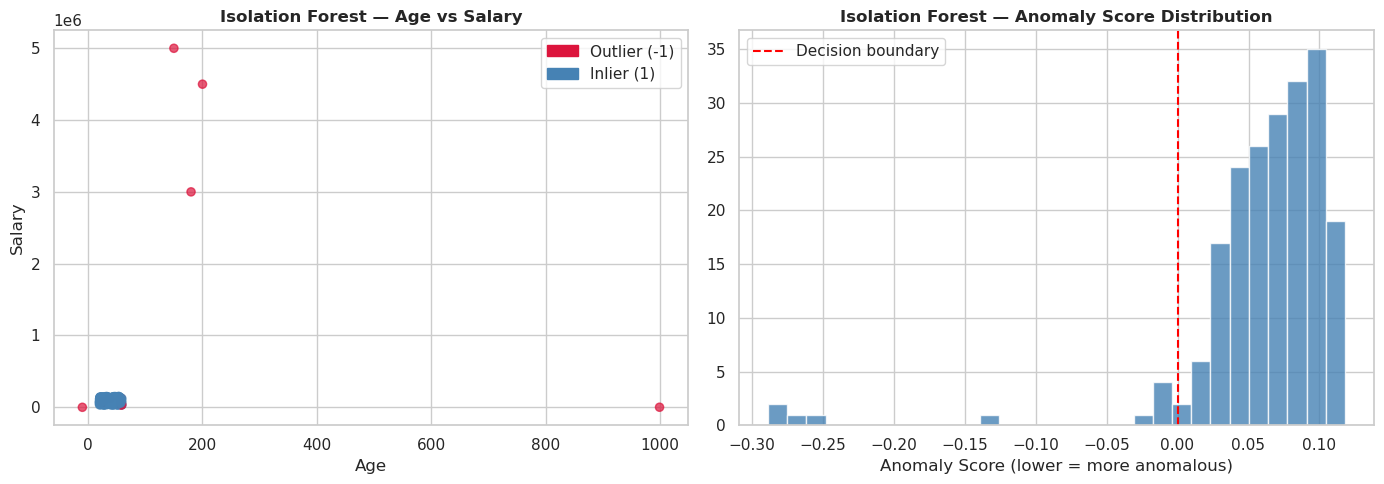

In [9]:
X = df[feature_cols]

iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
if_labels  = iso_forest.fit_predict(X)   # -1 = outlier, 1 = inlier
if_scores  = iso_forest.decision_function(X)

print(f'Isolation Forest — Outliers detected: {(if_labels == -1).sum()}')

# ── Scatter: Age vs Salary colored by IF labels ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = np.where(if_labels == -1, 'crimson', 'steelblue')
axes[0].scatter(df['Age'], df['Salary'], c=colors, alpha=0.7, s=35)
axes[0].set_xlabel('Age');  axes[0].set_ylabel('Salary')
axes[0].set_title('Isolation Forest — Age vs Salary', fontweight='bold')
red_patch  = mpatches.Patch(color='crimson',   label='Outlier (-1)')
blue_patch = mpatches.Patch(color='steelblue', label='Inlier (1)')
axes[0].legend(handles=[red_patch, blue_patch])

axes[1].hist(if_scores, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Decision boundary')
axes[1].set_title('Isolation Forest — Anomaly Score Distribution', fontweight='bold')
axes[1].set_xlabel('Anomaly Score (lower = more anomalous)')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 5️⃣ Local Outlier Factor (LOF)

> Compares **local density** of a point to its neighbors.
>
> ✅ Captures local anomalies that global methods miss.

LOF — Outliers detected: 10


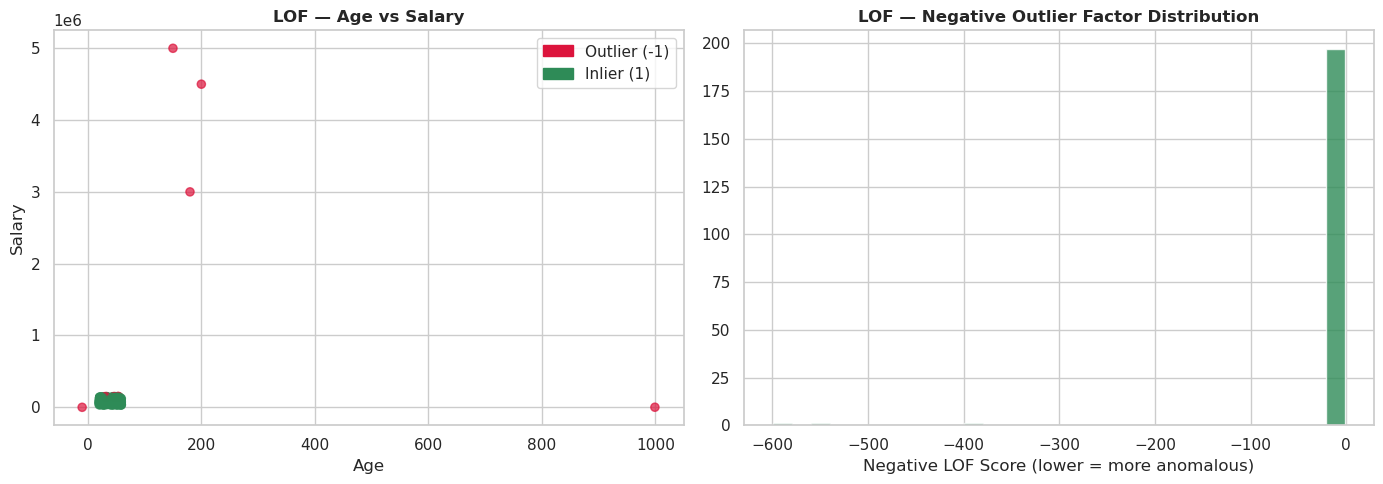

In [10]:
lof        = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_labels = lof.fit_predict(X)           # -1 = outlier, 1 = inlier
lof_scores = lof.negative_outlier_factor_ # more negative = more anomalous

print(f'LOF — Outliers detected: {(lof_labels == -1).sum()}')

# ── Plot ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = np.where(lof_labels == -1, 'crimson', 'seagreen')
axes[0].scatter(df['Age'], df['Salary'], c=colors, alpha=0.7, s=35)
axes[0].set_xlabel('Age');  axes[0].set_ylabel('Salary')
axes[0].set_title('LOF — Age vs Salary', fontweight='bold')
red_patch   = mpatches.Patch(color='crimson',  label='Outlier (-1)')
green_patch = mpatches.Patch(color='seagreen', label='Inlier (1)')
axes[0].legend(handles=[red_patch, green_patch])

axes[1].hist(lof_scores, bins=30, color='seagreen', edgecolor='white', alpha=0.8)
axes[1].set_title('LOF — Negative Outlier Factor Distribution', fontweight='bold')
axes[1].set_xlabel('Negative LOF Score (lower = more anomalous)')

plt.tight_layout()
plt.show()

---
## 6️⃣ DBSCAN

> Points not belonging to any dense cluster → **noise (label = -1)** = outlier.
>
> ✅ Works on arbitrary cluster shapes and spatial data.

DBSCAN — Clusters: 1 | Noise/Outliers: 4


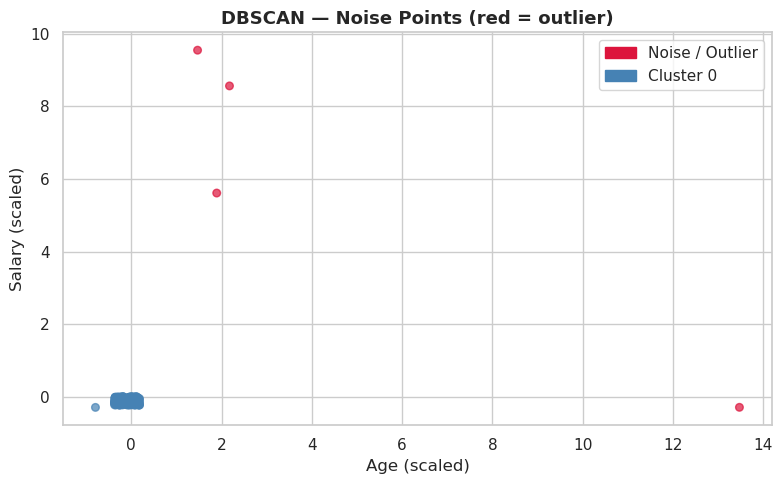

In [11]:
X_scaled = StandardScaler().fit_transform(X)
dbscan   = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise    = (db_labels == -1).sum()

print(f'DBSCAN — Clusters: {n_clusters} | Noise/Outliers: {n_noise}')

# ── Plot ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
palette = {-1: 'crimson', 0: 'steelblue', 1: 'seagreen', 2: 'orange'}
colors  = [palette.get(l, 'gray') for l in db_labels]
ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=colors, alpha=0.7, s=30)
ax.set_title('DBSCAN — Noise Points (red = outlier)', fontsize=13, fontweight='bold')
ax.set_xlabel('Age (scaled)');  ax.set_ylabel('Salary (scaled)')
red_patch  = mpatches.Patch(color='crimson',   label='Noise / Outlier')
blue_patch = mpatches.Patch(color='steelblue', label='Cluster 0')
ax.legend(handles=[red_patch, blue_patch])
plt.tight_layout()
plt.show()

---
## 7️⃣ Elliptic Envelope

> Fits a **Gaussian distribution** to data and uses **Mahalanobis distance** to flag outliers.
>
> ⚠️ Assumes multivariate Gaussian distribution.

Elliptic Envelope — Outliers detected: 10


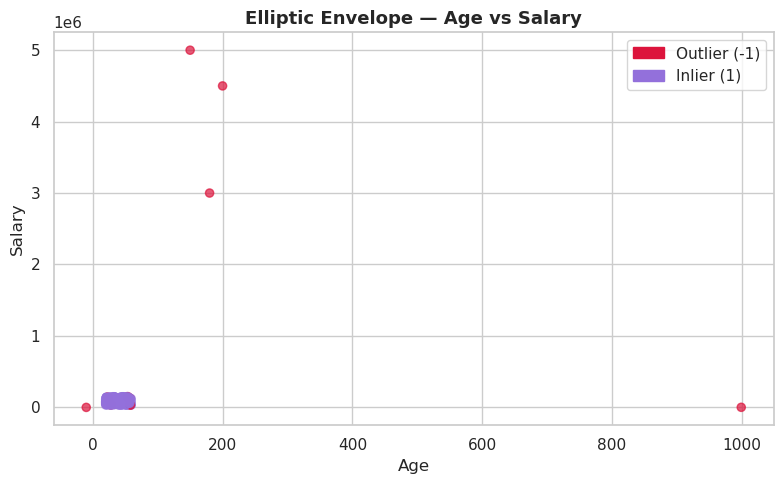

In [12]:
ee        = EllipticEnvelope(contamination=0.05, random_state=42)
ee_labels = ee.fit_predict(X)   # -1 = outlier, 1 = inlier

print(f'Elliptic Envelope — Outliers detected: {(ee_labels == -1).sum()}')

# ── Plot ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
colors = np.where(ee_labels == -1, 'crimson', 'mediumpurple')
ax.scatter(df['Age'], df['Salary'], c=colors, alpha=0.7, s=35)
ax.set_xlabel('Age');  ax.set_ylabel('Salary')
ax.set_title('Elliptic Envelope — Age vs Salary', fontsize=13, fontweight='bold')
red_patch    = mpatches.Patch(color='crimson',      label='Outlier (-1)')
purple_patch = mpatches.Patch(color='mediumpurple', label='Inlier (1)')
ax.legend(handles=[red_patch, purple_patch])
plt.tight_layout()
plt.show()

---
## 8️⃣ Winsorization (Capping)

> **Does not remove rows** — caps extreme values at percentile boundaries.
>
> ✅ Preserves dataset size while reducing outlier influence.

Before → Min: -1,000  Max: 5,000,000
After  → Min: 33,395  Max: 146,338


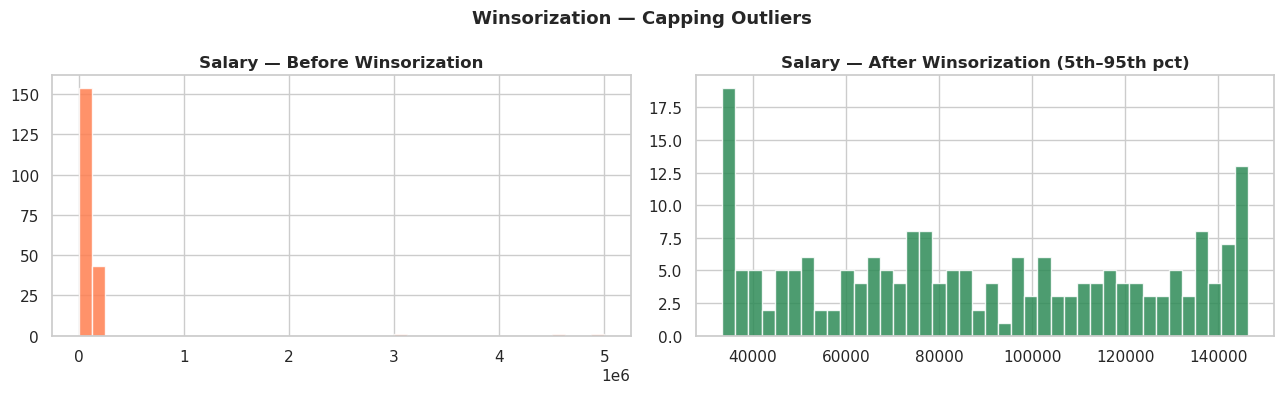

In [13]:
col        = 'Salary'
lower_pct  = df[col].quantile(0.05)
upper_pct  = df[col].quantile(0.95)

df_wins    = df.copy()
df_wins[col] = df_wins[col].clip(lower=lower_pct, upper=upper_pct)

print(f'Before → Min: {df[col].min():,.0f}  Max: {df[col].max():,.0f}')
print(f'After  → Min: {df_wins[col].min():,.0f}  Max: {df_wins[col].max():,.0f}')

# ── Before vs After ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df[col], bins=40, color='coral', edgecolor='white', alpha=0.85)
axes[0].set_title(f'{col} — Before Winsorization', fontweight='bold')

axes[1].hist(df_wins[col], bins=40, color='seagreen', edgecolor='white', alpha=0.85)
axes[1].set_title(f'{col} — After Winsorization (5th–95th pct)', fontweight='bold')

plt.suptitle('Winsorization — Capping Outliers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📊 9. Method Comparison — Outliers Detected per Technique

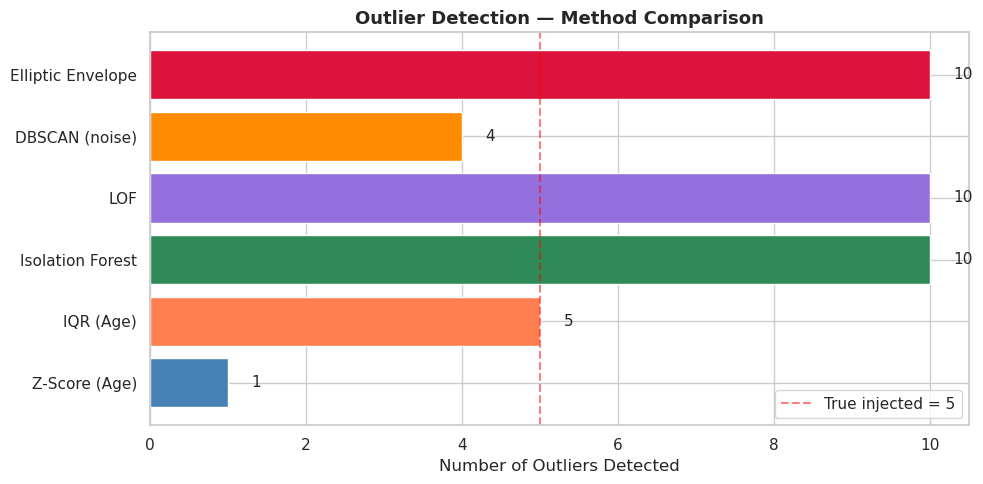


📊 Outliers Detected:
  Z-Score (Age)               : 1
  IQR (Age)                   : 5
  Isolation Forest            : 10
  LOF                         : 10
  DBSCAN (noise)              : 4
  Elliptic Envelope           : 10


In [14]:
# ── Recompute all masks ───────────────────────────────────────────────────
z_mask   = np.abs(stats.zscore(df['Age'])) > 3
Q1, Q3   = df['Age'].quantile(0.25), df['Age'].quantile(0.75)
IQR      = Q3 - Q1
iqr_mask = (df['Age'] < Q1 - 1.5 * IQR) | (df['Age'] > Q3 + 1.5 * IQR)

comparison = {
    'Z-Score (Age)'         : z_mask.sum(),
    'IQR (Age)'             : iqr_mask.sum(),
    'Isolation Forest'      : (if_labels  == -1).sum(),
    'LOF'                   : (lof_labels == -1).sum(),
    'DBSCAN (noise)'        : (db_labels  == -1).sum(),
    'Elliptic Envelope'     : (ee_labels  == -1).sum(),
}

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(list(comparison.keys()), list(comparison.values()),
               color=['steelblue','coral','seagreen','mediumpurple','darkorange','crimson'],
               edgecolor='white')
ax.set_xlabel('Number of Outliers Detected', fontsize=12)
ax.set_title('Outlier Detection — Method Comparison', fontsize=13, fontweight='bold')
ax.axvline(5, color='red', linestyle='--', alpha=0.5, label='True injected = 5')
ax.legend()

for bar, val in zip(bars, comparison.values()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=11)

plt.tight_layout()
plt.show()

print('\n📊 Outliers Detected:')
for method, count in comparison.items():
    print(f'  {method:28s}: {count}')

---
## 🗑️ 10. Removing Outliers & Cleaning

In [15]:
# ── Remove rows flagged as outliers by IQR on Age and Salary ─────────────
Q1_age, Q3_age = df['Age'].quantile(0.25), df['Age'].quantile(0.75)
IQR_age        = Q3_age - Q1_age
age_outliers   = (df['Age'] < Q1_age - 1.5*IQR_age) | (df['Age'] > Q3_age + 1.5*IQR_age)

Q1_sal, Q3_sal = df['Salary'].quantile(0.25), df['Salary'].quantile(0.75)
IQR_sal        = Q3_sal - Q1_sal
sal_outliers   = (df['Salary'] < Q1_sal - 1.5*IQR_sal) | (df['Salary'] > Q3_sal + 1.5*IQR_sal)

combined_mask  = age_outliers | sal_outliers
df_clean       = df[~combined_mask].reset_index(drop=True)

print(f'Original shape : {df.shape}')
print(f'After cleaning : {df_clean.shape}')
print(f'Rows removed   : {len(df) - len(df_clean)} ({(len(df)-len(df_clean))/len(df)*100:.1f}%)')

df_clean[feature_cols].describe().T

Original shape : (200, 4)
After cleaning : (195, 4)
Rows removed   : 5 (2.5%)


,count,mean,std,min,25%,50%,75%,max
Age,195.0000,39.6359,12.0952,20.0000,28.0000,41.0000,51.0000,59.0000
Salary,195.0000,87978.6513,36095.4489,30301.0000,58525.0000,84045.0000,119658.5000,149181.0000
Score,195.0000,50.0827,28.8590,0.5185,25.0556,50.1040,73.4342,99.5931


---
## ✅ 11. Summary & Best Practices

| Technique | Type | Dimensionality | Robust | Best For |
|-----------|------|:--------------:|:------:|----------|
| **Z-Score** | Statistical | Univariate | ❌ | Normal data |
| **IQR** | Statistical | Univariate | ✅ | Skewed data, EDA |
| **MAD** | Statistical | Univariate | ✅ | Small / noisy datasets |
| **Isolation Forest** | ML (Tree) | Multivariate | ✅ | High-dimensional |
| **LOF** | ML (Density) | Multivariate | ✅ | Varying density |
| **DBSCAN** | ML (Clustering) | Multivariate | ✅ | Spatial / noise |
| **Elliptic Envelope** | Statistical | Multivariate | ⚠️ | Gaussian assumption |
| **Winsorization** | Statistical | Univariate | ✅ | Cap, retain rows |

### 🔑 Golden Rules

1. **Visualize first** — box plots and scatter plots reveal outliers fast
2. **Understand context** — outliers may be signals (fraud, disease)
3. **Detect on train only** — never leak test statistics
4. **Cap before removing** — winsorization keeps your row count intact
5. **Prefer IQR over Z-Score** for skewed data
6. **Use Isolation Forest** for multivariate / high-dimensional problems
7. **Always check how many rows** are removed — losing >5% is a red flag

---

## 🔗 Next Steps

- ➡️ `Feature_Scaling/` — Scale features **after** handling outliers
- ➡️ `Feature_Engineering/` — Engineer features on clean data
- ➡️ `02_EDA/Univariate_Analysis/` — Deep-dive visual outlier exploration
- ➡️ `04_Unsupervised_Learning/DBSCAN/` — Full DBSCAN clustering